In [1]:
import tensorflow as tf

2026-02-18 22:25:39.839262: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-02-18 22:25:42.840466: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-02-18 22:25:43.913113: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


In [9]:
breeds = ["beagle","bernese_mountain_dog","doberman","labrador_retriever","siberian_husky"]

In [10]:
args = {"labels":"inferred",
        "label_mode":"categorical",
        "batch_size":32,
        "image_size":(256,256),
        "seed":1,
        "validation_split":.2,
        "class_names":breeds}

In [12]:
train = tf.keras.utils.image_dataset_from_directory("dog_images/images", subset = "training", **args)

Found 926 files belonging to 5 classes.
Using 741 files for training.


I0000 00:00:1771471841.178359   13612 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 9558 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 4070, pci bus id: 0000:01:00.0, compute capability: 8.9


In [13]:
test = tf.keras.utils.image_dataset_from_directory("dog_images/images", subset = "validation", **args)

Found 926 files belonging to 5 classes.
Using 185 files for validation.


In [14]:
first = train.take(1)
first

<_TakeDataset element_spec=(TensorSpec(shape=(None, 256, 256, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None, 5), dtype=tf.float32, name=None))>

In [16]:
images, labels = list(first)[0]

2026-02-18 22:33:12.864457: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


In [21]:
first_image = images[0]
first_image[:3, :3, 0]

<tf.Tensor: shape=(3, 3), dtype=float32, numpy=
array([[28.836777, 34.30638 , 35.53241 ],
       [17.165146, 20.022522, 21.235245],
       [23.966217, 18.18164 , 15.216293]], dtype=float32)>

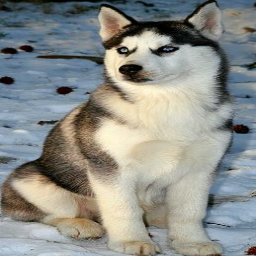

In [22]:
from PIL import Image

Image.fromarray(first_image.numpy().astype("uint8"))

In [23]:
labels[0]

<tf.Tensor: shape=(5,), dtype=float32, numpy=array([0., 0., 0., 0., 1.], dtype=float32)>